In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns
from scipy.stats import norm
import yfinance as yf
import cvxpy as cp

# **List of Tickers, Start Dates, and Frequencies**

We are taking 15 year monthly data on the largest ETFs and Mutual Funds in each financial sector. They are as follows


| Financial Sector | ETF | Mutual Fund|
|------------------|-----|------------|
| NASDAQ | `^IXIC` | `^IXIC` |
| Technology | `VGT` | `VITAX`|
| Financial Services | `XLF` |`VFAIX` |
| Consumer Cyclical | `XLY` |`BPTRX` |
| Consumer Defensive | `XLP` | `VCSAX`|
| Communication Services | `VOX` |`VTCAX` |
| Industrials | `XLI` |`VINAX` |
| Basic Materials | `XLB` |`VMIAX` |
| Energy |`XLE` |`VENAX` |
| Healthcare | `XLV` |`VGHCX` |
| Utilities | `XLU` | `VUIAX`|
| Real Estate | `VNQ` |`VGSLX` |

In [ ]:
etf_tickers_NASDAQ = ['^IXIC','VGT', 'XLF', 'XLY', 'XLV', 'VOX', 'XLI', 'XLP', 'XLE', 'VNQ', 'XLB', 'XLU']
etf_tickers = ['VGT', 'XLF', 'XLY', 'XLV', 'VOX', 'XLI', 'XLP', 'XLE', 'VNQ', 'XLB', 'XLU']
mf_tickers_NASDAQ = ['^IXIC', 'VITAX', 'VFAIX', 'BPTRX', 'VGHCX', 'VTCAX', 'VINAX', 'VCSAX', 'VENAX', 'VGSLX', 'VMIAX', 'VUIAX']
mf_tickers = ['VITAX', 'VFAIX', 'BPTRX', 'VGHCX', 'VTCAX', 'VINAX', 'VCSAX', 'VENAX', 'VGSLX', 'VMIAX', 'VUIAX']

start_date_15yr = '2009-12-01'
end_date = '2025-01-04'

day = '1d'
week = '1wk'
month = '1mo'
year = '1yr'

# **Data Ingestion**

In [ ]:
def import_stock_data(tickers, start_date, end_date, frequency):
  data = yf.download(tickers, start=start_date, end = end_date, interval=frequency, auto_adjust=True)
  data=data['Close']
  data = data.dropna()
  data = data.reindex(columns=tickers)
  names = tickers
  data.index = pd.to_datetime(data.index)
  return(data)

def annualize_data(data):
    data.index = pd.to_datetime(data.index)
    annual_data = data.groupby(data.index.year).first()
    annual_data.index = pd.to_datetime(annual_data.index.astype(str) + '-01-01')
    return annual_data

def log_returns(data):
    return (np.log(1+data.pct_change())).dropna()

def prices_cov_matrix(data):
  return(data.cov())

def returns_cov_matrix(data):
  data=log_returns(data)
  return(data.cov())

In [ ]:
log_returns_dict = {}

etf_data_nasdaq = import_stock_data(etf_tickers_NASDAQ, start_date_15yr, end_date, month)
etf_log_returns_nasdaq = log_returns(etf_data_nasdaq)
log_returns_dict['ETF with NASDAQ, 15 Year Monthly'] = etf_log_returns_nasdaq

etf_data = import_stock_data(etf_tickers, start_date_15yr, end_date, month)
etf_log_returns = log_returns(etf_data)
log_returns_dict['ETF, 15 Year Monthly'] = etf_log_returns

mf_data_nasdaq = import_stock_data(mf_tickers_NASDAQ, start_date_15yr, end_date, month)
mf_returns_nasdaq = log_returns(mf_data_nasdaq)
log_returns_dict['Mutual Fund with NASDAQ, 15 Year Monthly'] = mf_returns_nasdaq

mf_data = import_stock_data(mf_tickers, start_date_15yr, end_date, month)
mf_returns = log_returns(mf_data)
log_returns_dict['Mutual Fund, 15 Year Monthly'] = mf_returns

log_returns_dict['ETF with NASDAQ, 15 Year Monthly'].head()

# **Summary Tables**

Next, we calculate the summary statistics for our data. The data for the summary tables must be in log-returns

In [ ]:
def summary_table(data, frequency):
  total_return = np.exp(data.sum()) - 1
  num_years = (data.index[-1] - data.index[0]) / pd.Timedelta(days=365.25)
  annual_return = (total_return+1)**(1/num_years)-1
  variance = data.var()
  volatility = variance**(1/2)

  if frequency == day:
    scale=252
  elif frequency ==week:
    scale=52.18
  elif frequency ==month:
    scale=12
  elif frequency == year:
    scale=1
  annualized_variance = variance*scale
  annualized_volatility = annualized_variance**(1/2)

  summary = pd.DataFrame({
      'Total Return': (total_return.values)*100,
      'Yearly Return': (annual_return.values)*100,
      'Volatilty': volatility*100,
      'Annualized Volatility': annualized_volatility*100
  })
  return(summary)

In [ ]:
summary_tables_dict = {}

etf_nasdaq_summary = summary_table(log_returns_dict['ETF with NASDAQ, 15 Year Monthly'], month)
etf_nasdaq_summary.head()

,Total Return,Yearly Return,Volatilty,Annualized Volatility
Ticker,,,,
^IXIC,764.968834,15.468586,4.935771,17.098013
VGT,1197.644049,18.633402,5.299267,18.357199
XLF,478.281414,12.410522,5.614121,19.447886
XLY,845.504282,16.155898,5.338580,18.493382
XLV,513.080410,12.849273,3.913210,13.555758


# **Optimization**

Helper optimization functions that will be used in the next section

In [ ]:
def optimization_matrix(data, frequency):
    returns_vector = summary_table(data, frequency)['Yearly Return'].values / 100
    returns_vector = returns_vector.reshape(-1, 1)
    c = returns_cov_matrix(data).values
    n=c.shape[0]
    top=np.hstack([c, -returns_vector, -np.ones((n,1))])
    middle = np.hstack([returns_vector.T, np.array([[0]]), np.array([[0]])])
    bottom = np.hstack([np.ones((1,n)), np.array([[0]]), np.array([[0]])])
    final_matrix = np.vstack([top, middle, bottom])
    final_matrix=pd.DataFrame(final_matrix)
    return(final_matrix)

def optimization(data, frequency, mu):
    a = optimization_matrix(data, frequency)
    n=a.shape[0]
    b = np.zeros((n,1))
    b[-2]=mu
    b[-1]=1
    x = np.linalg.solve(a,b)
    weights=x[:-3]
    weights = pd.DataFrame(weights)
    return(weights)

def nonnegative_optimization(data, frequency, mu):
    summary = summary_table(data, frequency)
    r = summary['Yearly Return'].values / 100  # expected returns
    Sigma = returns_cov_matrix(data).values            # covariance matrix
    n = len(r)
    x = cp.Variable(n)
    constraints = [
        r @ x == mu,     # target return
        cp.sum(x) == 1,  # fully invested
        x >= 0           # long-only (no shorting)
    ]
    objective = cp.Minimize(cp.quad_form(x, Sigma))
    problem = cp.Problem(objective, constraints)
    problem.solve()
    if problem.status != cp.OPTIMAL:
        raise ValueError("Optimization did not converge")
    weights=x.value
    if frequency == day:
      scale=252
    elif frequency ==week:
      scale=52.18
    elif frequency ==month:
      scale=12
    elif frequency == year:
      scale=1
    variance = weights.T @ Sigma @ weights
    volatility = variance**(1/2)
    annualized_variance = variance*scale
    annualized_volatility = annualized_variance**(1/2)
    weights=weights*100
    weights = pd.DataFrame(weights, index=summary.index, columns=["Weight"])
    volatilatiies = pd.DataFrame({
        "Weight": [volatility.item()*100, annualized_volatility.item()*100]
    }, index=["Volatility", "Annualized Volatility"])
    weights = pd.concat([weights, volatilatiies])
    return weights

def multi_optimization(data, frequency, mu_list):
  results=[]
  for mu in mu_list:
      portfolio = nonnegative_optimization(data, frequency, mu)
      portfolio = portfolio.rename(columns={"Weight": mu*100})
      results.append(portfolio)
  combined = pd.concat(results, axis=1)
  combined.index.name = "Ticker"
  combined.reset_index(inplace=True)
  return combined

# **Efficient Frontier**

In [ ]:
def efficient_frontier(data, frequency):
  summary = summary_table(data, frequency)
  returns = summary['Yearly Return'] / 100
  mu_min = returns.min()
  mu_max = returns.max()
  mu_values = np.linspace(mu_min, mu_max, 200)
  volatilities = []
  yearly_returns = []

  for mu in mu_values:
        portfolio = nonnegative_optimization(data, frequency, mu)
        annualized_volatility = portfolio.loc["Annualized Volatility", "Weight"]  # convert from %
        yearly_return = mu * 100  # mu is in decimal, need to match axis in %

        volatilities.append(annualized_volatility)
        yearly_returns.append(yearly_return)
  plt.plot(volatilities, yearly_returns, marker = 'o', linestyle='-', color='b', markersize=4)
  plt.title('Efficient Frontier', fontsize=14)
  plt.ylabel('Yearly Return (%)', fontsize=12)
  plt.xlabel('Annualized Volatility (%)', fontsize=12)
  plt.show()

def efficient_frontier_cml(log_returns, frequency, risk_free_rate):

    # summary stats
    summary = summary_table(log_returns, frequency)
    returns = summary['Yearly Return'] / 100

    mu_min = returns.min()
    mu_max = returns.max()
    mu_values = np.linspace(mu_min, mu_max, 200)

    volatilities = []
    yearly_returns = []

    # compute frontier
    for mu in mu_values:
        portfolio = nonnegative_optimization(log_returns, frequency, mu)
        annualized_volatility = portfolio.loc["Annualized Volatility", "Weight"]
        yearly_return = mu * 100

        volatilities.append(annualized_volatility)
        yearly_returns.append(yearly_return)

    volatilities = np.array(volatilities).astype(float)
    yearly_returns = np.array(yearly_returns).astype(float)

    # Sharpe ratio
    sharpe_ratios = (yearly_returns/100 - risk_free_rate) / (volatilities/100)

    # portfolio points
    min_vol_idx = volatilities.argmin()
    max_sharpe_idx = sharpe_ratios.argmax()

    min_vol = volatilities[min_vol_idx]
    min_vol_ret = yearly_returns[min_vol_idx]

    max_sharpe_vol = volatilities[max_sharpe_idx]
    max_sharpe_ret = yearly_returns[max_sharpe_idx]

    # Capital Market Line
    cml_x = np.linspace(0, max_sharpe_vol*1.2, 200)
    slope = (max_sharpe_ret/100 - risk_free_rate) / (max_sharpe_vol/100)
    cml_y = risk_free_rate*100 + slope * cml_x

    # plotting
    plt.figure(figsize=(10, 6))
    plt.plot(volatilities, yearly_returns, 'bo', markersize=3, label='Efficient Frontier')
    plt.plot(cml_x, cml_y, 'r--', label='Capital Market Line')

    plt.scatter(max_sharpe_vol, max_sharpe_ret, color='green', s=120,
                label='Max Sharpe Portfolio', marker='*')

    plt.scatter(min_vol, min_vol_ret, color='purple', s=120,
                label='Minimum Volatility Portfolio', marker='*')

    plt.title(f"Efficient Frontier with Capital Market Line (Risk-Free = {risk_free_rate*100:.2f}%)")
    plt.xlabel("Annualized Volatility (%)")
    plt.ylabel("Yearly Return (%)")
    plt.legend()
    plt.grid(True)
    plt.show()

    # return optimal portfolios as DataFrame
    optimal = multi_optimization(
        log_returns,
        frequency,
        (max_sharpe_ret/100, min_vol_ret/100)
    )
    return optimal

/usr/local/lib/python3.12/dist-packages/pandas/core/internals/blocks.py:393: RuntimeWarning: divide by zero encountered in log
  result = func(self.values, **kwargs)
/usr/local/lib/python3.12/dist-packages/pandas/core/internals/blocks.py:393: RuntimeWarning: invalid value encountered in log
  result = func(self.values, **kwargs)
/usr/local/lib/python3.12/dist-packages/pandas/core/internals/blocks.py:393: RuntimeWarning: divide by zero encountered in log
  result = func(self.values, **kwargs)
/usr/local/lib/python3.12/dist-packages/pandas/core/internals/blocks.py:393: RuntimeWarning: invalid value encountered in log
  result = func(self.values, **kwargs)
/usr/local/lib/python3.12/dist-packages/pandas/core/internals/blocks.py:393: RuntimeWarning: divide by zero encountered in log
  result = func(self.values, **kwargs)
/usr/local/lib/python3.12/dist-packages/pandas/core/internals/blocks.py:393: RuntimeWarning: invalid value encountered in log
  result = func(self.values, **kwargs)
/usr/lo

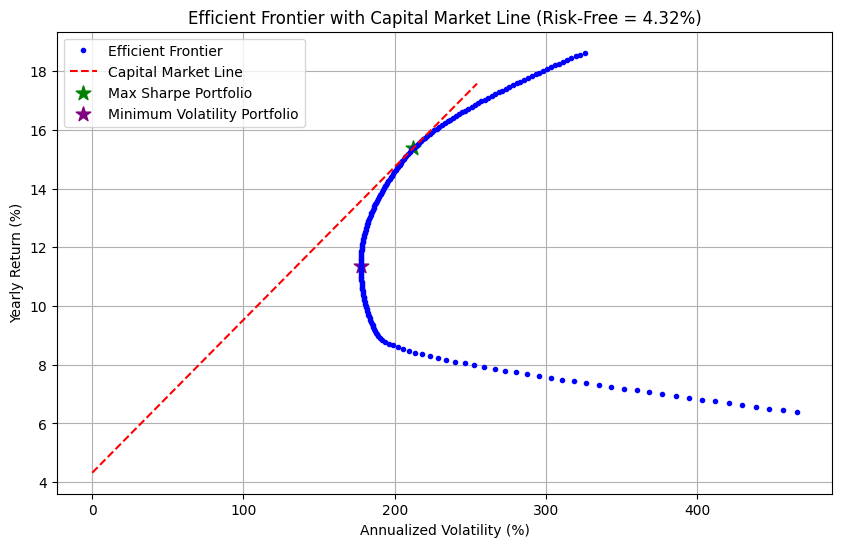

                   Ticker     15.371085      11.37013
0                   ^IXIC -1.390854e-19 -8.688921e-21
1                     VGT  4.588280e+01  1.266223e+01
2                     XLF -1.733087e-19 -1.559275e-20
3                     XLY  2.498867e-20  1.144260e-21
4                     XLV -8.900408e-20 -4.893840e-21
5                     VOX -1.240501e-19 -3.328674e-21
6                     XLI  3.962508e+01  2.111025e+01
7                     XLP -2.026276e-20 -2.919043e-21
8                     XLE -1.836031e-19  1.028524e+00
9                     VNQ -1.664863e-19 -2.295086e-21
10                    XLB -4.244734e-19  5.466562e+01
11                    XLU  1.449213e+01  1.053337e+01
12             Volatility  6.121495e+01  5.123479e+01
13  Annualized Volatility  2.120548e+02  1.774825e+02


/usr/local/lib/python3.12/dist-packages/pandas/core/internals/blocks.py:393: RuntimeWarning: divide by zero encountered in log
  result = func(self.values, **kwargs)
/usr/local/lib/python3.12/dist-packages/pandas/core/internals/blocks.py:393: RuntimeWarning: invalid value encountered in log
  result = func(self.values, **kwargs)
/usr/local/lib/python3.12/dist-packages/pandas/core/internals/blocks.py:393: RuntimeWarning: divide by zero encountered in log
  result = func(self.values, **kwargs)
/usr/local/lib/python3.12/dist-packages/pandas/core/internals/blocks.py:393: RuntimeWarning: invalid value encountered in log
  result = func(self.values, **kwargs)


In [ ]:
print(efficient_frontier_cml(log_returns_dict['ETF, 15 Year Monthly'], month, 0.0432))

# **Monte Carlo Simulation**

To perform the Monte Carlo simulation, we
1. Estimate log returns
2. Calculate the mean series and covariance matrix of the log returns
3. Choose a time step $\Delta t=\frac{1}{\text{steps per year}}$ and number of steps $N=\text{years}\times \text{steps per year}$
4. We compute the drift term using geometric brownian motion:
$$ \Delta \ln{S}\approx (\mu-\frac{1}{2}\sigma^2)\Delta t+\sigma\sqrt{\Delta t}Z$$
where $\mu$ is the mean log return per year and $\sigma^2$ is the variance of log return per year. Drift here is the vector of deterministic expected log-increments per step after applying the Ito correction $-\frac{1}{2}\sigma_i^2$
5. We take the Cholesky decomposition, which factors a symmetric positive-definite matrix into
$$ \Sigma\Delta t=LL^T$$
where $L$ is a lower-triangular matrix. We do this because, if $Z$ is a matrix of i.i.d. standard normals, then
$$ ZL^T\sim N(0,\Sigma\Delta t)$$
in other words, each row of $ZL^T$ is a correlated normal draw with covariance $\Sigma\Delta t$. We use this to turn independent shocks into correlated shocks across assets that match the covariance in our data.
6. We generate a vector of random normal variables $Z$, and multiply is by the Cholesky decomposition matrix to obtain a matrix whose rows are multivariate normal shocks with covariance $\Sigma\Delta t$. We add these random shocks to the drift term
$$ \Delta \ln{S_T}=(\mu-\frac{1}{2}\text{diag }\Sigma)\Delta t+\epsilon_t, \quad \epsilon_t\sim N(0,\Sigma\Delta t)$$
We save this vector at `correlated_returns`, which is the per-step log increments for each asset
7. We calculate the log returns path by multiplying the weights factor to the correlated returns, giving our portfolio's log-return increment per step
8. Because log returns add
$$\sum_t\Delta \ln{P_t}=ln{\left(\frac{P_T}{P_0}\right)}$$
we take the cumulative sum of `log_returns_path` and save is at `log_cumulative_returns`
9. Exponentiating brings the path back to levels:
$$P_t=P_0e^{\sum_{k\leq t}\Delta \ln{P_k}} $$
which provides us `portfolio_paths`

## Assumptions of Monte Carlo

1. Asset prices follow a Geometric Brownian Motion,
$$ d\ln{S_t}=(\mu-0.5\sigma^2)dt+\sigma dW_t $$
which means
* Returns are normally distributed over small time steps
* Price levels are lognormally distributed
* Expected drift and volatility are constant through time
2. Constant Mean, Variance, and Correlation
* The mean vector $\mu$ and covariance matrix $\Sigma$ are assumed to stay the same for the entire simulation horizon
* No regime shifts, no volatility clustering, no changing correlations
3. Returns are i.i.d (independent and identically distributed). At each step:
* Returns do not depend on previous returns (no memory)
* No autocorrelation, no momentum, no mean reversion
4. Multivariate Normal Shocks. Using the Cholesky decomposition assumes that
* Shocks to asset returns are jointly normally distributed
* Correlation structure between assets stays constant over time
5. Rebalancing to constant weights each period. Because you multiply the asset vector by weights every step:
* Portfolio is assumed to be rebalanced to the same weights at each time interval
* No transaction costs or frictions
6. Historical Estimates Predict the Future. You're assuming:
* The future distribution of returns matches historical averages and covariances
* No structural market change


In [ ]:
def monte_carlo_efficient_frontier(data, frequency, num_portfolios, risk_free_rate):
  returns = log_returns(data).dropna()
  mean_returns = returns.mean()
  cov_matrix = returns.cov()

  if frequency == day:
      scale = 252
  elif frequency == week:
      scale = 52
  elif frequency == month:
      scale = 12
  else:
      scale = 1

  mean_returns *= scale
  cov_matrix *= scale

  num_assets = len(mean_returns)
  results = np.zeros((num_portfolios, 3))  # return, volatility, Sharpe
  weights_record = []

  for i in range(num_portfolios):
      weights = np.random.random(num_assets)
      weights /= np.sum(weights)
      weights_record.append(weights)

      portfolio_return = np.sum(weights * mean_returns)
      portfolio_volatility = np.sqrt(weights.T @ cov_matrix @ weights)
      sharpe_ratio = (portfolio_return - risk_free_rate) / portfolio_volatility

      results[i] = [portfolio_return * 100, portfolio_volatility * 100, sharpe_ratio]

  results_df = pd.DataFrame(results, columns=['Return (%)', 'Volatility (%)', 'Sharpe Ratio'])
  weights_df = pd.DataFrame(weights_record, columns=data.columns)

  max_sharpe_idx = results_df['Sharpe Ratio'].idxmax()
  min_vol_idx = results_df['Volatility (%)'].idxmin()

  # Plotting
  plt.figure(figsize=(10, 6))
  plt.scatter(results_df['Volatility (%)'], results_df['Return (%)'], c=results_df['Sharpe Ratio'], cmap='viridis', alpha=0.5)
  plt.colorbar(label='Sharpe Ratio')
  plt.scatter(results_df.loc[max_sharpe_idx, 'Volatility (%)'], results_df.loc[max_sharpe_idx, 'Return (%)'],
                color='r', marker='*', s=200, label='Max Sharpe')
  plt.scatter(results_df.loc[min_vol_idx, 'Volatility (%)'], results_df.loc[min_vol_idx, 'Return (%)'],
                color='b', marker='*', s=200, label='Min Volatility')
  plt.title('Monte Carlo Simulated Efficient Frontier')
  plt.xlabel('Volatility (%)')
  plt.ylabel('Return (%)')
  plt.legend()
  plt.grid(True)
  plt.show()

  return results_df, weights_df

def monte_carlo_portfolio_paths(data, frequency, num_steps, num_simulations, num_years, initial_value):
    log_ret = log_returns(data).dropna()
    mu = log_ret.mean()
    cov = log_ret.cov()

    if frequency == 'day':
        steps_per_year = 252
    elif frequency == 'week':
        steps_per_year = 52
    elif frequency == 'month':
        steps_per_year = 12
    else:
        steps_per_year = 1

    mu = mu*steps_per_year
    cov = cov*steps_per_year

    dt = 1 / num_steps
    total_num_steps = int(num_years * num_steps)
    num_assets = len(mu)
    weights = np.repeat(1 / num_assets, num_assets)

    # Precomputed drift and Cholesky decomposition
    drift = (mu - 0.5 * np.diag(cov)) * dt
    chol = np.linalg.cholesky(cov * dt)

    # Run simulations
    portfolio_paths = np.zeros((num_simulations, total_num_steps))
    for i in range(num_simulations):
        Z = np.random.normal(size=(total_num_steps, num_assets))
        correlated_returns = Z @ chol.T + drift.values
        log_returns_path = correlated_returns @ weights
        log_cumulative_returns = np.cumsum(log_returns_path)
        portfolio_paths[i] = initial_value * np.exp(log_cumulative_returns)

    # Calculate annualized return and volatility
    end_values = portfolio_paths[:, -1]
    annualized_returns = (end_values / initial_value) ** (1 / num_years) - 1
    log_changes = np.log(portfolio_paths[:, 1:] / portfolio_paths[:, :-1])
    annualized_vol = np.std(log_changes, axis=1) * np.sqrt(steps_per_year)

    mean_return = np.mean(annualized_returns) * 100
    mean_volatility = np.mean(annualized_vol) * 100

    # Plotting
    plt.figure(figsize=(10, 6))
    for path in portfolio_paths:
        plt.plot(range(total_num_steps), path, alpha=0.2, color='teal')
    plt.title(f"Growth of $100,000:\n(Return: {mean_return:.1f}%, Volatility: {mean_volatility:.2f}%)\nNumber of Simulations: {num_simulations}")
    plt.xlabel("Months" if frequency == '1mo' else "Steps")
    plt.ylabel("Portfolio Value")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    return portfolio_paths, mean_return, mean_volatility

# **Example Usage**

The cells below demonstrate the full analysis pipeline for the ETF dataset (without NASDAQ benchmark).
Swap in any of the other datasets from `log_returns_dict` to reproduce the analysis for mutual funds or NASDAQ-inclusive versions.

In [ ]:
etf_data = log_returns_dict['ETF, 15 Year Monthly']

# Summary statistics
print(summary_table(etf_data, month))

# Optimal portfolios at selected target returns
print(multi_optimization(etf_data, month, (0.07, 0.09, 0.11, 0.13, 0.15, 0.17, 0.19)))

# Efficient frontier with Capital Market Line (risk-free rate = 4.32%)
print(efficient_frontier_cml(etf_data, month, 0.0432))

# Monte Carlo simulated efficient frontier (10,000 random portfolios)
print(monte_carlo_efficient_frontier(etf_data, month, 10000, 0.0432))

# Monte Carlo portfolio growth simulation (1,000 simulations, 10-year horizon, $100,000 initial investment)
print(monte_carlo_portfolio_paths(etf_data, month, 12, 1000, 10, 100000))